In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,BatchNormalization
from tensorflow.keras.optimizers import SGD
from matplotlib import pyplot as plt
from tensorflow.python.keras.saving.saved_model import metric_serialization

### Load Data

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

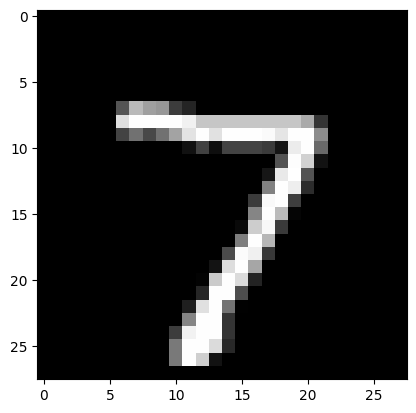

In [3]:
plt.imshow(X_test[0], cmap='gray')

### Processing The Data

In [4]:
X_train = X_train.reshape(60000,784).astype('float32')
X_valid = X_test.reshape(10000,784).astype('float32')

X_train /= 255
X_valid /= 255

In [5]:
n_classes = 10
y_train = to_categorical(y_train, n_classes)
y_valid = to_categorical(y_test,n_classes)

### Implementing the Neural Network

### first layer not using optimization  with 64 nuerons with 50,240  parameters with zero penalties. 77 % percent accuracy could be related to the fact that Layer 1 was overfitting

In [6]:
import warnings
warnings.filterwarnings('ignore')
model = Sequential()
# hidden layer
model.add(Dense(64, activation='relu', input_shape=(784,)))
model.add(BatchNormalization())

#second hidden layer
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

#output layer
model.add(Dense(10, activation='softmax'))
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,562 (217.04 KB)

 Trainable params: 55,306 (216.04 KB)

 Non-trainable params: 256 (1.00 KB)

### Implemented Dropout on first layer and reduced cross-entropy-loss from 244.65 to 0.08

In [ ]:
import warnings
warnings.filterwarnings('ignore')
model = Sequential()
# hidden layer
model.add(Dense(64, activation='relu', input_shape=(784,)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

#second hidden layer
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

#output layer
model.add(Dense(10, activation='softmax'))
model.summary()


In [7]:
model.compile(loss='categorical_crossentropy', optimizer = 'nadam', metrics = ['accuracy'])

In [8]:
model.fit(X_train, y_train, batch_size=128, epochs = 128, verbose =1, validation_data = (X_valid, y_valid))

Epoch 1/128
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 978us/step - accuracy: 0.8277 - loss: 0.5647 - val_accuracy: 0.9352 - val_loss: 0.2094
Epoch 2/128
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 901us/step - accuracy: 0.9182 - loss: 0.2769 - val_accuracy: 0.9517 - val_loss: 0.1561
Epoch 3/128
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 941us/step - accuracy: 0.9320 - loss: 0.2261 - val_accuracy: 0.9575 - val_loss: 0.1413
Epoch 4/128
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 930us/step - accuracy: 0.9412 - loss: 0.1977 - val_accuracy: 0.9607 - val_loss: 0.1240
Epoch 5/128
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - accuracy: 0.9460 - loss: 0.1822 - val_accuracy: 0.9632 - val_loss: 0.1224
Epoch 6/128
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 877us/step - accuracy: 0.9488 - loss: 0.1665 - val_accuracy: 0.9645 - val_loss: 0.1137
Epoch 7/128
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 931us/step - accuracy: 0.9529 - loss: 0.1551 - val_accuracy: 0.9661 - val_loss: 0.1088
Epoch 8/128
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 910us/step - accuracy: 0.9541 - loss: 0

In [9]:
test_loss, test_acc = model.evaluate(X_valid, y_valid, verbose=0)

In [10]:
print(f"Test loss: {test_loss:.4f} Test accuracy: {test_acc:.4f}")

Test loss: 0.0836 Test accuracy: 0.9779


In [11]:
predictions = model.predict(X_valid[:5], verbose=0)
predictions_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_valid)

Predicted classes:  [7 2 1 0 4]
True classes:  [7 2 1 0 4]